### Homework 2: Discover the Higgs Boson!

For this question, I have provided you with a (simplified) version of the simulated Higgs boson data challenge, run by Kaggle in 2014. The files, available in the "Data" folder, are called "Higgs_features.csv" and "Higgs_labels.csv". The labels are 0 and 1, corresponding to "no Higgs signal", and "Higgs signal".

1\. Read the data into two numpy arrays or data frames, one for features and one for labels.

2\. How many instances and features are in this data set?

3\. Plot the distribution of each feature for this data set in a histogram, in one plot. Add a legend (with labels "Feature 1", "Feature 2"...) and set the transparency of the histograms (property "alpha") to 0.5 for clarity. Hint: make sure you are plotting each column, not each row!

4\. Do you see anything unusual in the distribution of any of the features? What problem could this cause?

5\. How many positive (Higgs) events does your data set contain? Based on this, is the data set balanced or unbalanced?

6\. On the basis of your answer to 5, which evaluation metric (accuracy, precision, recall) would you like to pick for this data set? Justify your answer.

7\. Use a decision tree classifier as your model, and do five fold cross validation on your data, <b> using the scoring parameter you chose above</b>. Report the mean and standard deviation of the scores obtained for the five folds.

Note: If you simply set the parameter "cv = 5" in the cross_val_score function, this will divide the data in five sets using the first 20%, second 20%... etc of your data, which is not great if your data are in a specific order. Make sure you use cv = StratifiedKFold(shuffle=True, n_splits=5).


8\. We want to now take a look at the confusion matrix for your classifier. Generate the predicted label using the "cross_val_predict" function, then print the confusion matrix.

9\. Given your confusion matrix, how many true positives / true negatives / false positives / false negatives are there? Do you have more type I errors (false positives) than type II errors (false negatives)?

10\. Let's now switch to a SVC classifier. Leaving the parameters of the classifier at their default values, run a five-fold cross validation and report the scores just like you did above for the decision tree. (Note: SVMs are slow so this might take some time, a good 5 minutes on my laptop. If it takes too long, you can reduce the number of folds to 3). Which algorithm performs better? 

11\. Report the confusion matrix for the SVC algorithm. Do you notice a change in the distribution of the false positives and false negatives, with respect to the decision tree algorithm?

12\. We can now try to optimize the parameters of the SVC. Because it would otherwise take a long time, we can select the first 5% of the data set (after shuffling the data set). 

You can do it using the code below, but you need to change the original array names for features and targets to match yours. You will then produce the two arrays "Xlittle, ylittle".

13\. Set up and run a GridSearch CV with the following parameters: 

parameters = {'kernel':['linear','rbf'],'C':[1, 10, 100], 'gamma':[0.01, 0.1, 0.5], 'class_weight':[{1:1},{1:3},{1:5}]}

You can use the code from the particle ID with SVMs notebook, but remember to change the scoring parameter to match what you did above.

Note: this might take time! Set verbose = 2 in the GridSearchCV to follow the progress, and set njobs = 4 or more to speed up the process. 

#### Report the scores and parameters values of the best model.

14\. Based on what you found, would you recommend to use a Decision Tree Classifier or a Support Vector Classifier for this problem?

Extra Credit: The object GridSearchCV (probably called clf or model in your code) that you created above has an attribute "cv\_results\_" that allows you to visualize the scores for every combination of parameters; we did it in the SVM notebook. Based on this, which parameter has the highest impact (induces the largest change) on the performance of the SVC? Do you think it might be worth optimizing it further?

(24999, 8)


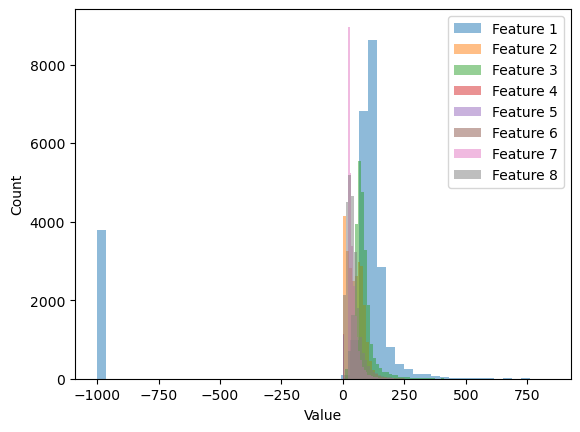

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# step 1: read the data
features = pd.read_csv('../Data/Higgs_features.csv')
labels = pd.read_csv('../Data/Higgs_labels.csv')

# 2: how many instances & features are in the data set
print(features.shape)

# 3: plot distributions of each feature
for i, col in enumerate(features.columns):
    plt.hist(features[col], bins=50, alpha=0.5, label=f"Feature {i+1}")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

#4: anything unusual about the distribution?
>Feature 1 has a lot of data points near -1000 which is unusual because none of the other features have any negative data points. 

In [20]:
# 5: how many positive higgs events does the data set contain?
print(labels.sum().sum())

8474


#6: What evaluation metric to use?
>There are 8474/24999 positive events. When there is a small number of positive events, recall can be better than accuracy because it will have a better chance at returning positive events even if there are more false positve events returned as well. 

In [ ]:
# 7: train a decisionn tree
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True)
tree = DecisionTreeClassifier(random_state=42)

tree_scores = cross_val_score(tree, features, labels, cv=cv, scoring='recall')
print("mean: ", tree_scores.mean().round(3))
print("std: ", tree_scores.std().round(3))

mean:  0.64
std:  0.011


In [32]:
# 8: make confusion matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred = cross_val_predict(tree, features, labels, cv=cv)
confusion_matrix = confusion_matrix(labels, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

Confusion Matrix:
 [[13467  3058]
 [ 3094  5380]]


#9: evaluate confusion matrix
>true positives: 13467, 
true negatives: 5380, 
false positives: 3094, 
false negatives: 3058

>there are more false positives (type I errors) than false negatives (type II errors) but not by much

In [35]:
# 10: SVC + SVM
from sklearn.svm import SVC

svc = SVC(random_state=45453)
scores_svc = cross_val_score(svc, features, labels, cv=cv, scoring='recall')
print("mean:", scores_svc.mean().round(3))
print("std:", scores_svc.std().round(3))

/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array w

mean: 0.61
std: 0.008


In [36]:
# 11: make confusion matrix again
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred_svc = cross_val_predict(svc, features, labels, cv=cv)
confusion_matrix_svc = confusion_matrix(labels, y_pred_svc)
print("Confusion Matrix:\n", confusion_matrix_svc)

/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array w

Confusion Matrix:
 [[14578  1947]
 [ 3297  5177]]


#11 cont.
>The svc increased the false positives slightly but cut the false negatives by about 1/3. 

In [43]:
# 12: shuffle and take 5%
from sklearn.utils import shuffle

ftrs, trgt = shuffle(features.values, labels.values, random_state = 13)

number_samples = ftrs.shape[0]

Xlittle, ylittle = ftrs[:int(number_samples*0.05),:], trgt[:int(number_samples*0.05)]

Xlittle.shape #check that everything went as expected


(1249, 8)

In [45]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'kernel': ['linear','rbf'],
    'C': [1, 10, 100],
    'gamma': [0.01, 0.1, 0.5],
    'class_weight': [{1:1}, {1:3}, {1:5}]
}

svc_little = SVC()

grid = GridSearchCV(
    svc_little, 
    parameters, 
    cv=5, 
    scoring='recall', 
    verbose=2,
    n_jobs=4
)
grid.fit(Xlittle, ylittle)

print("best recall:", grid.best_score_)
print("best parameters:", grid.best_params_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array w

[CV] END C=1, class_weight={1: 1}, gamma=0.01, kernel=linear; total time=   2.9s
[CV] END C=1, class_weight={1: 1}, gamma=0.01, kernel=linear; total time=   3.0s


/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END ...C=1, class_weight={1: 1}, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...C=1, class_weight={1: 1}, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...C=1, class_weight={1: 1}, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...C=1, class_weight={1: 1}, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...C=1, class_weight={1: 1}, gamma=0.01, kernel=rbf; total time=   0.0s


...

[CV] END C=100, class_weight={1: 3}, gamma=0.01, kernel=linear; total time= 1.3min


/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END C=100, class_weight={1: 3}, gamma=0.1, kernel=linear; total time= 1.3min


/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


KeyboardInterrupt: 

#14: which one to use?
>My computer couldnt run the second one (it took over 12 minutes) so I would use the first model. I think that the first model has good enough bias and it is much quicker to run. 